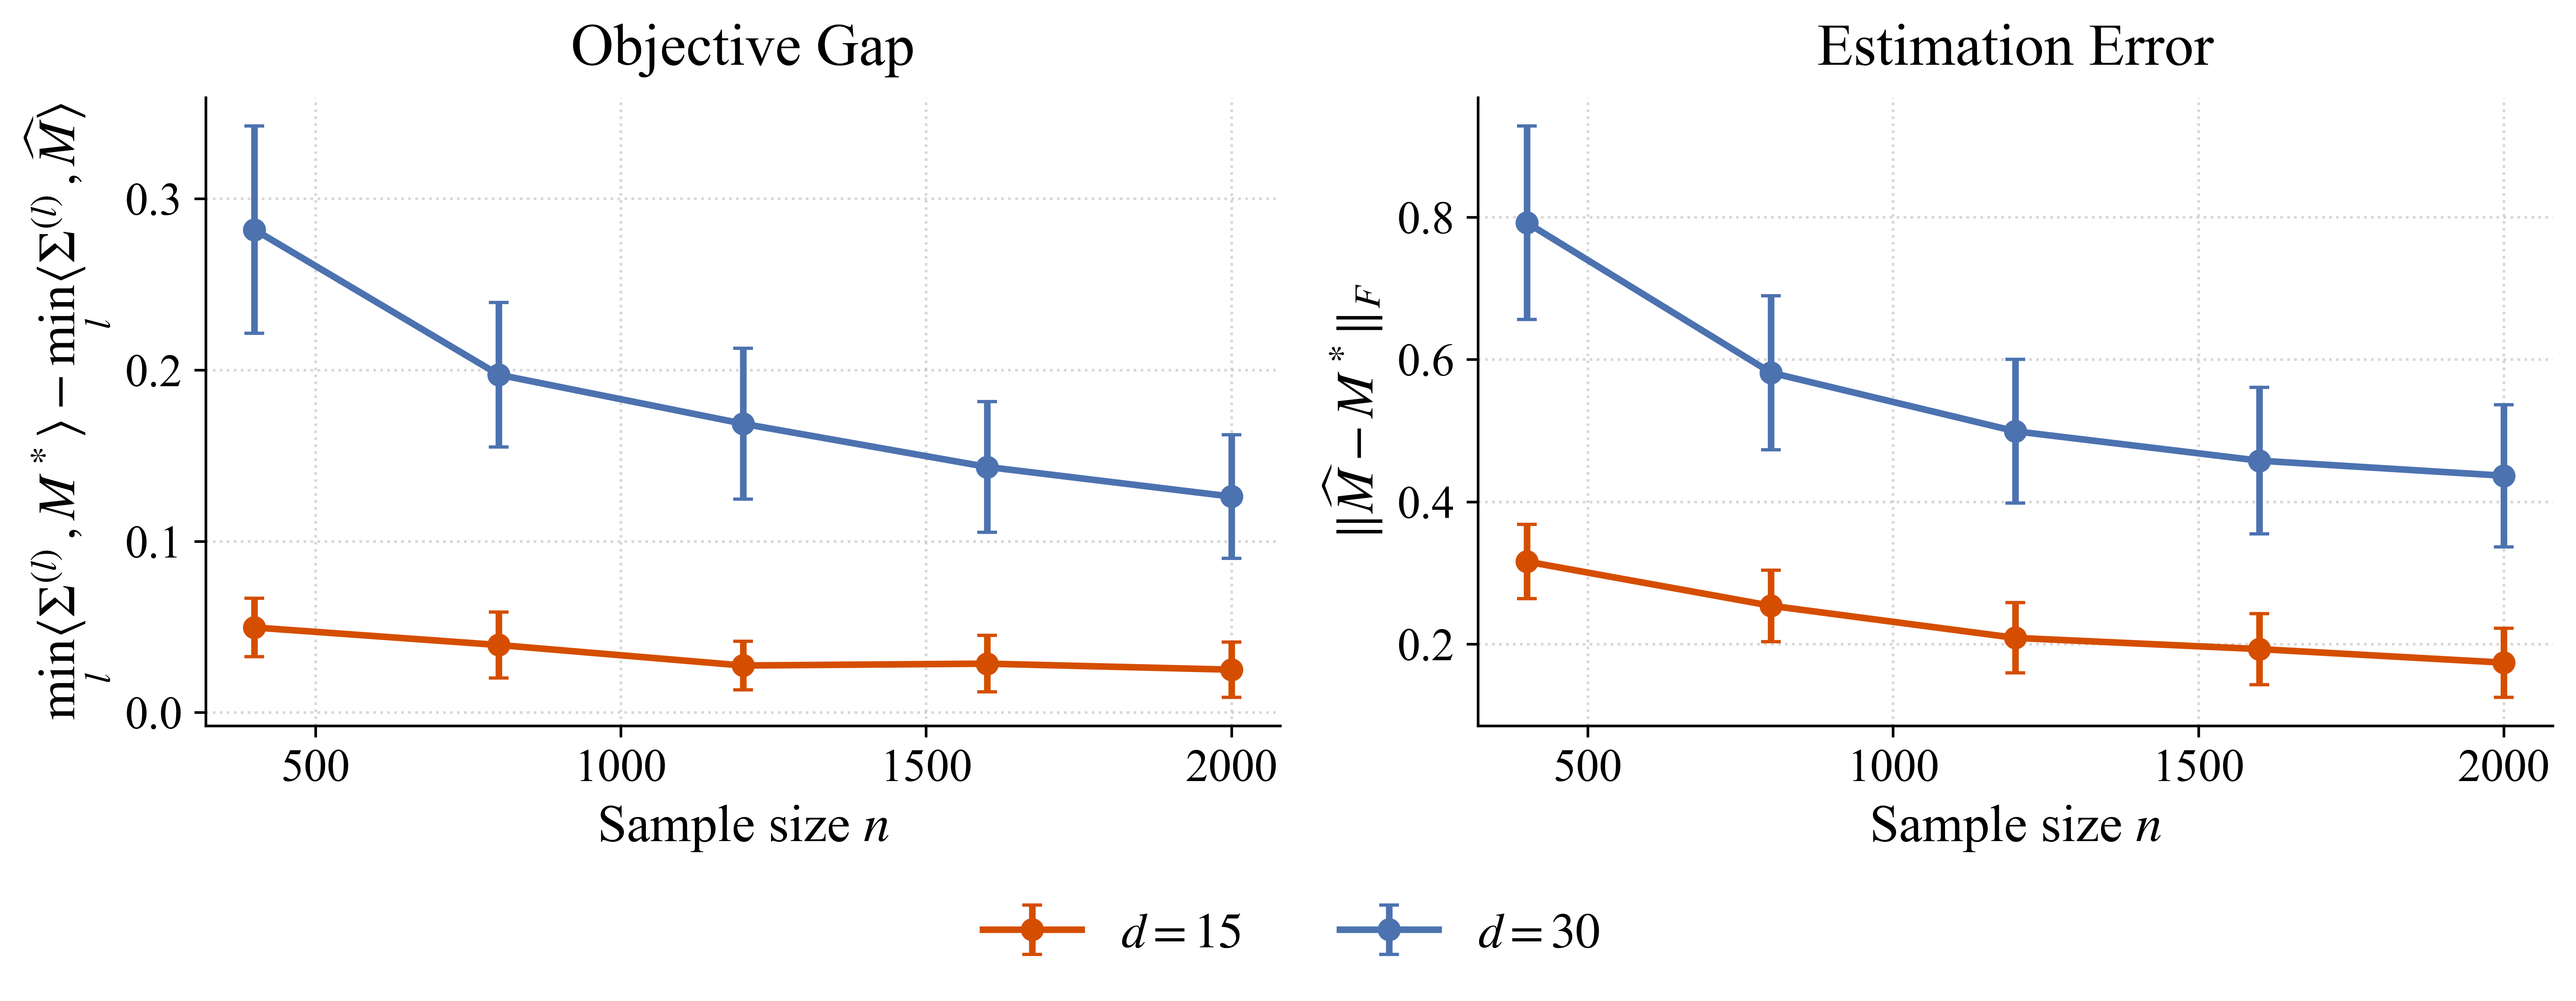

In [ ]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt

# Settings
n_list = [400, 800, 1200, 1600, 2000]
p_list = [15, 30]
results_dir = "../saved_results"

# Aggregate stats
val_gap_mean, val_gap_std = {p: [] for p in p_list}, {p: [] for p in p_list}
est_gap_mean, est_gap_std = {p: [] for p in p_list}, {p: [] for p in p_list}

for p in p_list:
    for n in n_list:
        fname = os.path.join(results_dir, f"results-Finite_n{n}_p{p}.pkl")
        if not os.path.exists(fname):
            print(f"Missing file: {fname}")
            val_gap_mean[p].append(np.nan); val_gap_std[p].append(np.nan)
            est_gap_mean[p].append(np.nan); est_gap_std[p].append(np.nan)
            continue
        with open(fname, "rb") as f:
            results = pickle.load(f)
        vg = np.array([r["val_gap"] for r in results])
        eg = np.array([r["est_gap"] for r in results])
        val_gap_mean[p].append(vg.mean()); val_gap_std[p].append(vg.std())
        est_gap_mean[p].append(eg.mean()); est_gap_std[p].append(eg.std())

# ------------------------------------------------------------
# NeurIPS-ish style
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "figure.dpi": 600,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 15,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
    "lines.linewidth": 2.0,
})

# Colors for each p
p_colors = {15: "#D54E00", 30:  "#4C72B0"}

# ------------------------------------------------------------
# Create subplots
# ------------------------------------------------------------
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4))
plt.subplots_adjust(bottom=0.25, wspace=0.3)

# 1) Objective gap
for p in p_list:
    ax0.errorbar(
        n_list, val_gap_mean[p], yerr=val_gap_std[p],
        fmt='-o', color=p_colors[p], capsize=3, label=rf"$d={p}$"
    )
ax0.set_xlabel(r"Sample size $n$")
ax0.set_ylabel(r"$\min_l \langle \Sigma^{(l)}, M^* \rangle - \min_l \langle \Sigma^{(l)}, \widehat{M} \rangle$")
ax0.set_title(r"Objective Gap", pad=10)
ax0.grid(True, linestyle=":", linewidth=0.8, alpha=0.5)
for s in ["top", "right"]: ax0.spines[s].set_visible(False)

# 2) Estimation error
for p in p_list:
    ax1.errorbar(
        n_list, est_gap_mean[p], yerr=est_gap_std[p],
        fmt='-o', color=p_colors[p], capsize=3, label=rf"$d={p}$"
    )
ax1.set_xlabel(r"Sample size $n$")
ax1.set_ylabel(r"$\|\widehat{M} - M^*\|_F$")
ax1.set_title(r"Estimation Error", pad=10)
ax1.grid(True, linestyle=":", linewidth=0.8, alpha=0.5)
for s in ["top", "right"]: ax1.spines[s].set_visible(False)

# Shared legend
handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center",
           bbox_to_anchor=(0.5, -0.07), ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig("summary_Finite.png", bbox_inches="tight", dpi=600)
plt.show()


In [ ]:
# --- settings (adjust if needed) ---
results_dir = "../saved_results"
n_list = [400, 800, 1200, 1600, 2000]
p_list = [15, 30]

# containers
cert_mean  = {p: [] for p in p_list}
cert_std   = {p: [] for p in p_list}
proj_mean  = {p: [] for p in p_list}
proj_std   = {p: [] for p in p_list}

for p in p_list:
    for n in n_list:
        fname = os.path.join(results_dir, f"results-Finite_n{n}_p{p}.pkl")
        if not os.path.exists(fname):
            raise FileNotFoundError(f"Missing file: {fname}")
        with open(fname, "rb") as f:
            results = pickle.load(f)

        certificates = np.array([r["certificate"] for r in results])
        proj_losses  = np.array([r["proj_loss"] for r in results])

        cert_mean[p].append(certificates.mean())
        cert_std[p].append(certificates.std(ddof=0))
        proj_mean[p].append(proj_losses.mean())
        proj_std[p].append(proj_losses.std(ddof=0))


In [35]:
# --- format numbers ---
def fmt(x, digits=3):
    return f"{x:.{digits}f}"

# --- build LaTeX table ---
lines = []
lines.append(r"\begin{table}[ht]")
lines.append(r"\centering")
lines.append(r"\resizebox{0.9\linewidth}{!}{%")
lines.append(r"\begin{tabular}{c|" + "c" * len(n_list) + "|" + "c" * len(n_list) + "}")
lines.append(r"\hline")

# Header groups
header_p15 = r"\multicolumn{" + str(len(n_list)) + r"}{c|}{$p=15$}"
header_p30 = r"\multicolumn{" + str(len(n_list)) + r"}{c}{$p=30$}"
lines.append(r" & " + header_p15 + r" & " + header_p30 + r" \\")
lines.append(r"\hline")

# n values
lines.append(r"$n$ & " + " & ".join(str(n) for n in n_list) + " & " + " & ".join(str(n) for n in n_list) + r" \\")
lines.append(r"\hline")

# Certificate row
row_cert = [r"\texttt{certificate}"]
row_cert += [fmt(cert_mean[15][i]) for i in range(len(n_list))]
row_cert += [fmt(cert_mean[30][i]) for i in range(len(n_list))]
lines.append(" & ".join(row_cert) + r" \\")

# Projection loss row
row_proj = [r"\texttt{proj\_loss}"]
row_proj += [fmt(proj_mean[15][i]) for i in range(len(n_list))]
row_proj += [fmt(proj_mean[30][i]) for i in range(len(n_list))]
lines.append(" & ".join(row_proj) + r" \\")

lines.append(r"\hline")
lines.append(r"\end{tabular}")
lines.append(r"}")
lines.append(r"\caption{Summary of certificate and projection loss across $(n,p)$ configurations.}")
lines.append(r"\label{tab:finite-certificate-projloss}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print(latex_table)

\begin{table}[ht]
\centering
\resizebox{0.9\linewidth}{!}{%
\begin{tabular}{c|ccccc|ccccc}
\hline
 & \multicolumn{5}{c|}{$p=15$} & \multicolumn{5}{c}{$p=30$} \\
\hline
$n$ & 400 & 800 & 1200 & 1600 & 2000 & 400 & 800 & 1200 & 1600 & 2000 \\
\hline
\texttt{certificate} & 0.025 & 0.024 & 0.018 & 0.016 & 0.015 & 0.068 & 0.068 & 0.071 & 0.061 & 0.057 \\
\texttt{proj\_loss} & 0.017 & 0.020 & 0.016 & 0.018 & 0.018 & 0.103 & 0.084 & 0.091 & 0.085 & 0.083 \\
\hline
\end{tabular}
}
\caption{Summary of certificate and projection loss across $(n,p)$ configurations.}
\label{tab:finite-certificate-projloss}
\end{table}
